# ML-Guided Paired CDR3 Library Design

This notebook uses a **pairwise Ridge regression model** trained on the double-mutant DMS data
to derive improved per-(position, amino-acid) scores for IUPAC codon selection.

## Why this improves on the heuristic design

The original `abDMS_CDR3_tcraft_paired_opool_design.ipynb` computes a *position-level* synergy bonus:
it asks "do alpha position *i* and beta position *j* tend to interact positively?" — averaged over all
amino acid identities at those positions.

This notebook instead fits:
```
log2fc(α_i=a, β_j=b) = w_α(i,a) + w_β(j,b) + w_αβ(i,a,j,b)
```
learning **amino-acid-specific** interchain interactions.
The marginal score for `(chain, pos, aa)` is then the average predicted binding over enriched partner
amino acids — a more accurate input to IUPAC codon selection.

## Caveats
- The model improves **interchain** epistasis resolution; it cannot improve intrachain extrapolation
  (multi-site sequences within one chain still assume additivity — same as the heuristic design).
- If cross-validated R² is < 0.25 for a peptide, the model has not learned much beyond the additive
  baseline and the marginals will closely resemble the original single-mutant scores.
- This is **one-shot model-guided design**, not iterative active learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import defaultdict
from itertools import product
from sklearn.model_selection import KFold

NB_DIR   = Path('/cluster/project/reddy/marluca/NGS_pipeline/notebooks')
DATA_DIR = Path('/cluster/project/reddy/marluca/NGS_pipeline/data/P3620_LUCA-TCRDMF5-abDMS/04_variant_labeling')
OUT_DIR  = NB_DIR / 'opool_designs_tcraft_ml'
OUT_DIR.mkdir(exist_ok=True)
print(f'Output: {OUT_DIR}')

Output: /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft_ml


In [3]:
PEPTIDES = ['DRG01','DRG04','GIG01','GIG02','GIG03','GIG04','GIG05']

WT_ALPHA  = 'AVNFGGGKLI'
WT_BETA   = 'ASSLSFGTEAF'
ALPHA_LEN = len(WT_ALPHA)
BETA_LEN  = len(WT_BETA)

ENRICHMENT_COL = {p: 'enrich_pos1x_vs_neg' for p in PEPTIDES}
ENRICHMENT_COL['GIG02'] = 'enrich_pos2x_vs_neg'
PSEUDOCOUNT = 1e-3

# ── Design parameters (match original notebook) ───────────────────────────
TARGET_DIVERSITY  = 10_000_000
MAX_DIVERSITY     = 15_000_000
MIN_SCORE         = 0.3
K_MAX             = 8
SYN_WEIGHT        = 0.5      # kept for reference; not used by ML score fn
TIER1_FRAC        = 0.33
STOP_PENALTY      = 10.0
EFFICIENCY_THRESH = 0.3
TOP_K             = 0

TIER1_EXCLUDE = {'alpha': {0}, 'beta': {0, 1}}

print(f'Alpha WT: {WT_ALPHA}  ({ALPHA_LEN} aa)')
print(f'Beta  WT: {WT_BETA}  ({BETA_LEN} aa)')
print(f'{len(PEPTIDES)} peptides: {PEPTIDES}')

Alpha WT: AVNFGGGKLI  (10 aa)
Beta  WT: ASSLSFGTEAF  (11 aa)
7 peptides: ['DRG01', 'DRG04', 'GIG01', 'GIG02', 'GIG03', 'GIG04', 'GIG05']


## Genetic Code and IUPAC Utilities

Copied verbatim from the original design notebook.

In [4]:
GENETIC_CODE = {
    'ATA':'I','ATC':'I','ATT':'I','ATG':'M',
    'ACA':'T','ACC':'T','ACG':'T','ACT':'T',
    'AAC':'N','AAT':'N','AAA':'K','AAG':'K',
    'AGC':'S','AGT':'S','AGA':'R','AGG':'R',
    'CTA':'L','CTC':'L','CTG':'L','CTT':'L',
    'CCA':'P','CCC':'P','CCG':'P','CCT':'P',
    'CAC':'H','CAT':'H','CAA':'Q','CAG':'Q',
    'CGA':'R','CGC':'R','CGG':'R','CGT':'R',
    'GTA':'V','GTC':'V','GTG':'V','GTT':'V',
    'GCA':'A','GCC':'A','GCG':'A','GCT':'A',
    'GAC':'D','GAT':'D','GAA':'E','GAG':'E',
    'GGA':'G','GGC':'G','GGG':'G','GGT':'G',
    'TCA':'S','TCC':'S','TCG':'S','TCT':'S',
    'TTC':'F','TTT':'F','TTA':'L','TTG':'L',
    'TAC':'Y','TAT':'Y','TAA':'*','TAG':'*',
    'TGC':'C','TGT':'C','TGA':'*','TGG':'W',
}
IUPAC_BASES = {
    'A':{'A'},'C':{'C'},'G':{'G'},'T':{'T'},
    'R':{'A','G'},'Y':{'C','T'},'S':{'G','C'},'W':{'A','T'},
    'K':{'G','T'},'M':{'A','C'},
    'B':{'C','G','T'},'D':{'A','G','T'},'H':{'A','C','T'},'V':{'A','C','G'},
    'N':{'A','C','G','T'},
}

def decode_iupac(triplet):
    codons = [b1+b2+b3 for b1 in IUPAC_BASES[triplet[0]]
                        for b2 in IUPAC_BASES[triplet[1]]
                        for b3 in IUPAC_BASES[triplet[2]]]
    aas, stops = set(), 0
    for c in codons:
        aa = GENETIC_CODE.get(c,'?')
        if aa == '*': stops += 1
        else: aas.add(aa)
    return aas, stops/len(codons)

ALL_IUPAC = list(IUPAC_BASES.keys())
IUPAC_PROPS = {}
for _t in product(ALL_IUPAC, repeat=3):
    _triplet = ''.join(_t)
    _aas, _sf = decode_iupac(_triplet)
    if _aas:
        IUPAC_PROPS[_triplet] = {'aas': frozenset(_aas), 'stop_frac': _sf}

print(f'Pre-computed {len(IUPAC_PROPS)} valid IUPAC triplets')

Pre-computed 3370 valid IUPAC triplets


## Load Data: Single-Mutant Effects and Paired Epistasis

In [5]:
def load_single_effects(pep_list):
    result = {}
    for pep in pep_list:
        df  = pd.read_csv(DATA_DIR / f'{pep}.variant_labeling.csv')
        col = ENRICHMENT_COL[pep]
        if col not in df.columns: col = 'enrich_pos1x_vs_neg'
        df['log2e']     = np.log2(df[col].clip(lower=PSEUDOCOUNT))
        baseline        = df['log2e'].mean()
        df['log2e_dev'] = df['log2e'] - baseline
        rows = []
        for _, r in df.iterrows():
            v = r['log2e_dev']
            aseq, bseq = r['alpha_aa'], r['beta_aa']
            if aseq != WT_ALPHA:
                for pos in range(ALPHA_LEN):
                    if aseq[pos] != WT_ALPHA[pos]:
                        rows.append(('alpha', pos, aseq[pos], v)); break
            if bseq != WT_BETA:
                for pos in range(BETA_LEN):
                    if bseq[pos] != WT_BETA[pos]:
                        rows.append(('beta', pos, bseq[pos], v)); break
        fx = (pd.DataFrame(rows, columns=['chain','position','aa','log2e_dev'])
              .groupby(['chain','position','aa'])['log2e_dev']
              .agg(log2fc='mean', n_variants='count').reset_index())
        result[pep] = fx
    return result

print('Loading single-mutant effects...')
SINGLE_FX = load_single_effects(PEPTIDES)
print(f'Done. DRG01: {len(SINGLE_FX["DRG01"])} entries')
SINGLE_FX['DRG01'].head(4)

Loading single-mutant effects...
Done. DRG01: 399 entries


,chain,position,aa,log2fc,n_variants
0,alpha,0,C,0.117227,100
1,alpha,0,D,0.072407,73
2,alpha,0,E,-0.145926,106
3,alpha,0,F,0.188084,123


In [9]:
def compute_epistasis(pep_list):
    result = {}
    for pep in pep_list:
        df  = pd.read_csv(DATA_DIR / f'{pep}.variant_labeling.csv')
        col = ENRICHMENT_COL[pep]
        if col not in df.columns: col = 'enrich_pos1x_vs_neg'
        df['log2e']     = np.log2(df[col].clip(lower=PSEUDOCOUNT))
        baseline        = df['log2e'].mean()
        df['log2e_dev'] = df['log2e'] - baseline
        fx = SINGLE_FX[pep].set_index(['chain','position','aa'])['log2fc'].to_dict()
        rows = []
        for _, r in df.iterrows():
            aseq, bseq = r['alpha_aa'], r['beta_aa']
            if aseq == WT_ALPHA or bseq == WT_BETA: continue
            apos = aaa = bpos = baa = None
            for pos in range(ALPHA_LEN):
                if aseq[pos] != WT_ALPHA[pos]: apos, aaa = pos, aseq[pos]; break
            for pos in range(BETA_LEN):
                if bseq[pos] != WT_BETA[pos]: bpos, baa = pos, bseq[pos]; break
            if apos is None or bpos is None: continue
            ma = fx.get(('alpha', apos, aaa), 0.0)
            mb = fx.get(('beta',  bpos, baa), 0.0)
            obs = r['log2e_dev']
            rows.append({'alpha_pos': apos, 'aa_alpha': aaa,
                         'beta_pos':  bpos, 'aa_beta':  baa,
                         'log2fc_obs': obs, 'log2fc_exp': ma+mb,
                         'epistasis': obs - (ma+mb)})
        result[pep] = pd.DataFrame(rows)
    return result

print('Computing paired epistasis...')
EPISTASIS = compute_epistasis(PEPTIDES)
print(f'Done. DRG01: {len(EPISTASIS["DRG01"]):,} pairs')
EPISTASIS['DRG01'].head(4)

Computing paired epistasis...
Done. DRG01: 30,317 pairs


,alpha_pos,aa_alpha,beta_pos,aa_beta,log2fc_obs,log2fc_exp,epistasis
0,1,A,1,A,2.289790,2.896811,-0.607021
1,1,C,1,A,4.988507,1.362625,3.625882
2,1,E,1,A,-2.625310,-0.788783,-1.836527
3,1,F,1,A,-2.625310,-0.435898,-2.189412


In [10]:
import torch

# ── GPU detection ────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f'GPU:  {props.name}')
    print(f'VRAM: {props.total_memory / 1e9:.1f} GB')
else:
    print('No CUDA GPU detected — running on CPU (still fast due to compact solver).')

# ── Feature-space constants ───────────────────────────────────────────────
AAS_ORDERED  = list('ACDEFGHIKLMNPQRSTVWY')
_aa_ord      = {aa: i for i, aa in enumerate(AAS_ORDERED)}
N_AA         = len(AAS_ORDERED)
N_ALPHA_FEAT = ALPHA_LEN * N_AA     # 10 × 20 = 200
N_BETA_FEAT  = BETA_LEN  * N_AA     # 11 × 20 = 220
N_INTERACT   = N_ALPHA_FEAT * N_BETA_FEAT  # 44,000

print(f'\nFeature counts: {N_ALPHA_FEAT} α-main  +  {N_BETA_FEAT} β-main  '
      f'+  {N_INTERACT:,} interchain  =  {N_ALPHA_FEAT+N_BETA_FEAT+N_INTERACT:,} total')
print(f'Reduced system: {N_ALPHA_FEAT + N_BETA_FEAT} × {N_ALPHA_FEAT + N_BETA_FEAT}  '
      f'(Schur complement of interaction block)')


# ── Compact Ridge solver ──────────────────────────────────────────────────

def _suff_stats(af, bf, y, device):
    """
    Compute sufficient statistics for Ridge regression via GPU scatter_add.

    Returns: cnt_a (200,), cnt_b (220,), cnt_i (44000,),
             Xty_a (200,), Xty_b (220,), Xty_i (44000,)
    All as numpy arrays.
    """
    af_t = torch.tensor(af,  dtype=torch.long,    device=device)
    bf_t = torch.tensor(bf,  dtype=torch.long,    device=device)
    y_t  = torch.tensor(y,   dtype=torch.float64, device=device)
    ii_t = af_t * N_BETA_FEAT + bf_t  # interaction index

    ones = torch.ones(len(y), dtype=torch.float64, device=device)

    cnt_a  = torch.zeros(N_ALPHA_FEAT, dtype=torch.float64, device=device).scatter_add_(0, af_t, ones)
    cnt_b  = torch.zeros(N_BETA_FEAT,  dtype=torch.float64, device=device).scatter_add_(0, bf_t, ones)
    cnt_i  = torch.zeros(N_INTERACT,   dtype=torch.float64, device=device).scatter_add_(0, ii_t, ones)
    Xty_a  = torch.zeros(N_ALPHA_FEAT, dtype=torch.float64, device=device).scatter_add_(0, af_t, y_t)
    Xty_b  = torch.zeros(N_BETA_FEAT,  dtype=torch.float64, device=device).scatter_add_(0, bf_t, y_t)
    Xty_i  = torch.zeros(N_INTERACT,   dtype=torch.float64, device=device).scatter_add_(0, ii_t, y_t)

    return (cnt_a.cpu().numpy(), cnt_b.cpu().numpy(), cnt_i.cpu().numpy(),
            Xty_a.cpu().numpy(), Xty_b.cpu().numpy(), Xty_i.cpu().numpy())


def _schur_solve(cnt_a, cnt_b, cnt_i, Xty_a, Xty_b, Xty_i, alpha_reg):
    """
    Solve Ridge normal equations via Schur complement.

    Reduces the (N_ALPHA_FEAT + N_BETA_FEAT + N_INTERACT) = 44,420-dim system
    to a (N_ALPHA_FEAT + N_BETA_FEAT) = 420-dim system by analytically
    eliminating the interaction weights.

    Returns: w_a (200,), w_b (220,), w_i (200, 220)
    """
    cnt_ab  = cnt_i.reshape(N_ALPHA_FEAT, N_BETA_FEAT)    # (200, 220)
    Xty_mat = Xty_i.reshape(N_ALPHA_FEAT, N_BETA_FEAT)

    denom = cnt_ab + alpha_reg
    s_ab  = np.where(cnt_ab > 0, cnt_ab / denom, 0.0)   # cnt_ab / (cnt_ab + α)
    h_ab  = np.where(cnt_ab > 0, Xty_mat / denom, 0.0)  # Xᵀy_i / (cnt_ab + α)

    # Schur complement matrix (420 × 420)
    M_ab   = alpha_reg * s_ab                             # (200, 220) off-diagonal block
    diag_a = cnt_a + alpha_reg - (cnt_ab * s_ab).sum(1)  # (200,)
    diag_b = cnt_b + alpha_reg - (cnt_ab * s_ab).sum(0)  # (220,)

    rhs_a  = Xty_a - (cnt_ab * h_ab).sum(1)              # (200,)
    rhs_b  = Xty_b - (cnt_ab * h_ab).sum(0)              # (220,)

    p = N_ALPHA_FEAT + N_BETA_FEAT   # 420
    M = np.zeros((p, p))
    np.fill_diagonal(M[:N_ALPHA_FEAT, :N_ALPHA_FEAT], diag_a)
    np.fill_diagonal(M[N_ALPHA_FEAT:, N_ALPHA_FEAT:], diag_b)
    M[:N_ALPHA_FEAT, N_ALPHA_FEAT:] = M_ab
    M[N_ALPHA_FEAT:, :N_ALPHA_FEAT] = M_ab.T

    w_small = np.linalg.solve(M, np.concatenate([rhs_a, rhs_b]))
    w_a     = w_small[:N_ALPHA_FEAT]
    w_b     = w_small[N_ALPHA_FEAT:]
    w_i     = h_ab - s_ab * (w_a[:, None] + w_b[None, :])  # (200, 220)

    return w_a, w_b, w_i


class CompactRidge:
    """
    Ridge regression for the paired-chain DMS feature structure.

    Stores only three weight arrays:
      w_a_ : (N_ALPHA_FEAT,)         alpha main effects
      w_b_ : (N_BETA_FEAT,)          beta main effects
      w_i_ : (N_ALPHA_FEAT, N_BETA_FEAT)  interaction effects

    Prediction is simple array indexing — no matrix multiplication needed.
    """

    def __init__(self, alpha=1.0):
        self.alpha  = alpha
        self.alpha_ = alpha
        self.w_a_   = None
        self.w_b_   = None
        self.w_i_   = None

    def fit(self, af, bf, y, device=DEVICE):
        stats = _suff_stats(af, bf, y, device)
        self.w_a_, self.w_b_, self.w_i_ = _schur_solve(*stats, self.alpha)
        return self

    def predict(self, af, bf):
        return self.w_a_[af] + self.w_b_[bf] + self.w_i_[af, bf]

    def score(self, af, bf, y):
        pred = self.predict(af, bf)
        ss_res = np.sum((y - pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1.0 - ss_res / ss_tot


def fit_ridge_cv(af, bf, y, alphas, n_splits=5, device=DEVICE):
    """
    Fit CompactRidge with alpha selected by k-fold CV.

    Since the solve is exact and trivially fast (420×420), we can afford
    n_splits × len(alphas) independent fits in seconds.

    Returns (best_model, best_alpha, best_cv_r2).
    """
    from sklearn.model_selection import KFold
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Total sufficient statistics (used to compute per-fold train stats)
    stats_total = _suff_stats(af, bf, y, device)

    cv_r2 = np.zeros((len(alphas), n_splits))

    for fi, (train_idx, val_idx) in enumerate(kf.split(af)):
        af_v, bf_v, y_v = af[val_idx], bf[val_idx], y[val_idx]

        # Held-out stats (only need to scatter the validation subset)
        stats_val   = _suff_stats(af_v, bf_v, y_v, device)
        # Training stats = total minus held-out (avoids recomputing over train set)
        stats_train = tuple(a - b for a, b in zip(stats_total, stats_val))

        for ai, alpha_reg in enumerate(alphas):
            w_a, w_b, w_i = _schur_solve(*stats_train, alpha_reg)
            pred = w_a[af_v] + w_b[bf_v] + w_i[af_v, bf_v]
            ss_res = np.sum((y_v - pred) ** 2)
            ss_tot = np.sum((y_v - y_v.mean()) ** 2)
            cv_r2[ai, fi] = 1.0 - ss_res / ss_tot

    mean_r2   = cv_r2.mean(axis=1)
    best_ai   = int(np.argmax(mean_r2))
    best_alpha = alphas[best_ai]

    model = CompactRidge(alpha=best_alpha).fit(af, bf, y, device=device)
    return model, best_alpha, float(mean_r2[best_ai])


# ── Prediction grid ───────────────────────────────────────────────────────
# All 44,000 possible single-mutation-per-chain combinations.
# Stored as simple integer index arrays (no sparse matrix needed).
_apos_grid = np.repeat(np.arange(ALPHA_LEN), N_AA * BETA_LEN * N_AA)
_aai_grid  = np.tile(np.repeat(np.arange(N_AA), BETA_LEN * N_AA), ALPHA_LEN)
_bpos_grid = np.tile(np.repeat(np.arange(BETA_LEN), N_AA), ALPHA_LEN * N_AA)
_bai_grid  = np.tile(np.arange(N_AA), ALPHA_LEN * N_AA * BETA_LEN)

_AF_GRID   = (_apos_grid * N_AA + _aai_grid).astype(np.int32)   # alpha feature index
_BF_GRID   = (_bpos_grid * N_AA + _bai_grid).astype(np.int32)   # beta  feature index
_AA_ALPHA_GRID = np.array(AAS_ORDERED)[_aai_grid]
_AA_BETA_GRID  = np.array(AAS_ORDERED)[_bai_grid]

print(f'\nPrediction grid: {len(_AF_GRID):,} (α_pos,α_aa,β_pos,β_aa) combinations')

Device: cuda
GPU:  NVIDIA GeForce RTX 2080 Ti
VRAM: 11.3 GB

Feature counts: 200 α-main  +  220 β-main  +  44,000 interchain  =  44,420 total
Reduced system: 420 × 420  (Schur complement of interaction block)

Prediction grid: 44,000 (α_pos,α_aa,β_pos,β_aa) combinations


## ML Model: Compact Closed-Form Ridge Regression (GPU-accelerated)

### Why sklearn's RidgeCV was slow

sklearn solves the 44,420-dimensional normal equations iteratively (conjugate gradient).
With 25 fits (5 alphas × 5 CV folds) × 7 peptides = 175 CG solves, each on a
nearly-singular 44 K-dimensional system, it can take hours.

### The Schur complement reduction

Every training sample has **exactly one alpha mutation and one beta mutation**.
This means the normal equations have a block structure:

```
[ D_α + αI   A_αβ      A_αi   ] [w_α]   [Xᵀy_α]
[ A_αβᵀ      D_β + αI  A_βi   ] [w_β] = [Xᵀy_β]
[ A_αiᵀ      A_βiᵀ     D_i+αI ] [w_i]   [Xᵀy_i]
```

Because D_i and A_αi both depend only on the co-occurrence matrix (cnt_ab), the
third block can be solved analytically for w_i as a function of w_α and w_β:

```
w_i[a,b] = (Xᵀy_i[a,b] - cnt_ab[a,b]·(w_α[a]+w_β[b])) / (cnt_ab[a,b] + α)
```

Substituting back gives a **420×420 reduced system** (200 alpha + 220 beta features).
This is solved exactly in microseconds.

### GPU usage

PyTorch is used for the `scatter_add` operations that aggregate sufficient statistics
(counts and label sums by feature group) over n=30K–120K samples — the only step that
touches the full dataset.

**On ETH Euler:** load a CUDA module before launching JupyterHub, e.g.:
```bash
module load cuda/12.1 eth_proxy
pip install torch --index-url https://download.pytorch.org/whl/cu121
```
The code falls back to CPU automatically if no GPU is available.

In [11]:
import time

ALPHAS = [0.01, 0.1, 1, 10, 100, 1000]

ML_MODELS = {}
ML_R2     = {}

print(f'{"Peptide":<8}  {"n_pairs":>9}  {"best α":>8}  {"CV R²":>8}  {"time (s)":>10}')
print('─' * 52)

for pep in PEPTIDES:
    df    = EPISTASIS[pep].dropna(subset=['log2fc_obs'])
    valid = df['aa_alpha'].isin(_aa_ord) & df['aa_beta'].isin(_aa_ord)
    df    = df[valid]

    af = (df['alpha_pos'].values * N_AA
          + df['aa_alpha'].map(_aa_ord).values).astype(np.int32)
    bf = (df['beta_pos'].values  * N_AA
          + df['aa_beta'].map(_aa_ord).values).astype(np.int32)
    y  = df['log2fc_obs'].values.astype(np.float64)

    t0 = time.perf_counter()
    model, best_alpha, r2 = fit_ridge_cv(af, bf, y, ALPHAS, n_splits=5, device=DEVICE)
    elapsed = time.perf_counter() - t0

    ML_MODELS[pep] = model
    ML_R2[pep]     = r2
    print(f'{pep:<8}  {len(y):>9,}  {best_alpha:>8.2g}  {r2:>8.3f}  {elapsed:>10.2f}')

print('\nR² ≥ 0.3 → meaningful interchain signal beyond the additive baseline.')

Peptide     n_pairs    best α     CV R²    time (s)
────────────────────────────────────────────────────
DRG01        30,317        10     0.172        1.62
DRG04        29,408        10     0.179        0.10
GIG01        28,341        10     0.184        0.09
GIG02        30,847        10     0.134        0.09
GIG03        25,922        10     0.134        0.09
GIG04        29,614        10     0.221        0.08
GIG05        27,950        10     0.181        0.09

R² ≥ 0.3 → meaningful interchain signal beyond the additive baseline.


## Compute ML Marginal Scores

For IUPAC codon selection we need a single score per `(chain, pos, aa)`.

**Alpha marginal(i, a)** = mean predicted log2fc over all beta (pos, aa) combinations,
weighted by clipped-positive beta single-mutant log2fc.

**Beta marginal(j, b)** = same, averaging over the alpha side.

This captures the interchain context: an amino acid that is globally enriched as a single mutant
but consistently *penalised* by its best-scoring beta partners will receive a lower marginal score.

In [12]:
def compute_ml_marginals(pep, weight_by_score=True):
    """
    For each (chain, pos, aa), compute marginal predicted binding score.

    Prediction for each grid point is a simple array lookup on the three
    weight arrays — instant, no matrix multiplication.

    Alpha marginal(i, a): mean predicted score over all beta (pos, aa),
    weighted by clipped-positive beta single-mutant log2fc.
    Beta  marginal(j, b): same, averaging over the alpha side.
    """
    model = ML_MODELS[pep]

    # Predictions for the full 44,000-combination grid — just array indexing
    preds = model.predict(_AF_GRID, _BF_GRID)  # (44000,)

    pairs = pd.DataFrame({
        'alpha_pos': _apos_grid,
        'aa_alpha':  _AA_ALPHA_GRID,
        'beta_pos':  _bpos_grid,
        'aa_beta':   _AA_BETA_GRID,
        'predicted': preds,
    })

    fx = SINGLE_FX[pep]
    if weight_by_score:
        alpha_w = fx[fx['chain'] == 'alpha'].set_index(['position', 'aa'])['log2fc'].clip(lower=0)
        beta_w  = fx[fx['chain'] == 'beta' ].set_index(['position', 'aa'])['log2fc'].clip(lower=0)
        pairs['w_alpha'] = (pairs.set_index(['alpha_pos', 'aa_alpha'])
                            .index.map(alpha_w).fillna(0).values)
        pairs['w_beta']  = (pairs.set_index(['beta_pos',  'aa_beta'])
                            .index.map(beta_w).fillna(0).values)
    else:
        pairs['w_alpha'] = pairs['w_beta'] = 1.0

    def _wm(grp, wcol):
        w = grp[wcol].values; v = grp['predicted'].values; s = w.sum()
        return (v * w).sum() / s if s > 0 else v.mean()

    alpha_rows = [
        {'chain': 'alpha', 'position': ap, 'aa': aa, 'ml_score': _wm(g, 'w_beta')}
        for (ap, aa), g in pairs.groupby(['alpha_pos', 'aa_alpha'], sort=False)
    ]
    beta_rows = [
        {'chain': 'beta', 'position': bp, 'aa': ba, 'ml_score': _wm(g, 'w_alpha')}
        for (bp, ba), g in pairs.groupby(['beta_pos', 'aa_beta'], sort=False)
    ]
    return pd.concat([pd.DataFrame(alpha_rows), pd.DataFrame(beta_rows)], ignore_index=True)


print('Computing ML marginals for all peptides...')
ML_MARGINALS = {pep: compute_ml_marginals(pep) for pep in PEPTIDES}
print('Done.')
print('\nTop-6 alpha marginals — DRG01:')
print(ML_MARGINALS['DRG01'].query("chain=='alpha'").nlargest(6, 'ml_score')
      [['position', 'aa', 'ml_score']].to_string(index=False))
print('\nTop-6 beta marginals — DRG01:')
print(ML_MARGINALS['DRG01'].query("chain=='beta'").nlargest(6, 'ml_score')
      [['position', 'aa', 'ml_score']].to_string(index=False))

Computing ML marginals for all peptides...
Done.

Top-6 alpha marginals — DRG01:
 position aa  ml_score
        1  A  5.399666
        9  L  5.097364
        0  G  4.873133
        3  M  4.867684
        7  V  4.861158
        7  L  4.816486

Top-6 beta marginals — DRG01:
 position aa  ml_score
        4  V  6.314060
        4  L  5.769065
        7  R  5.226287
        4  I  4.703159
        7  K  4.673941
        8  K  4.587353


## Diagnostics: ML Marginals vs. Original Single-Mutant Scores

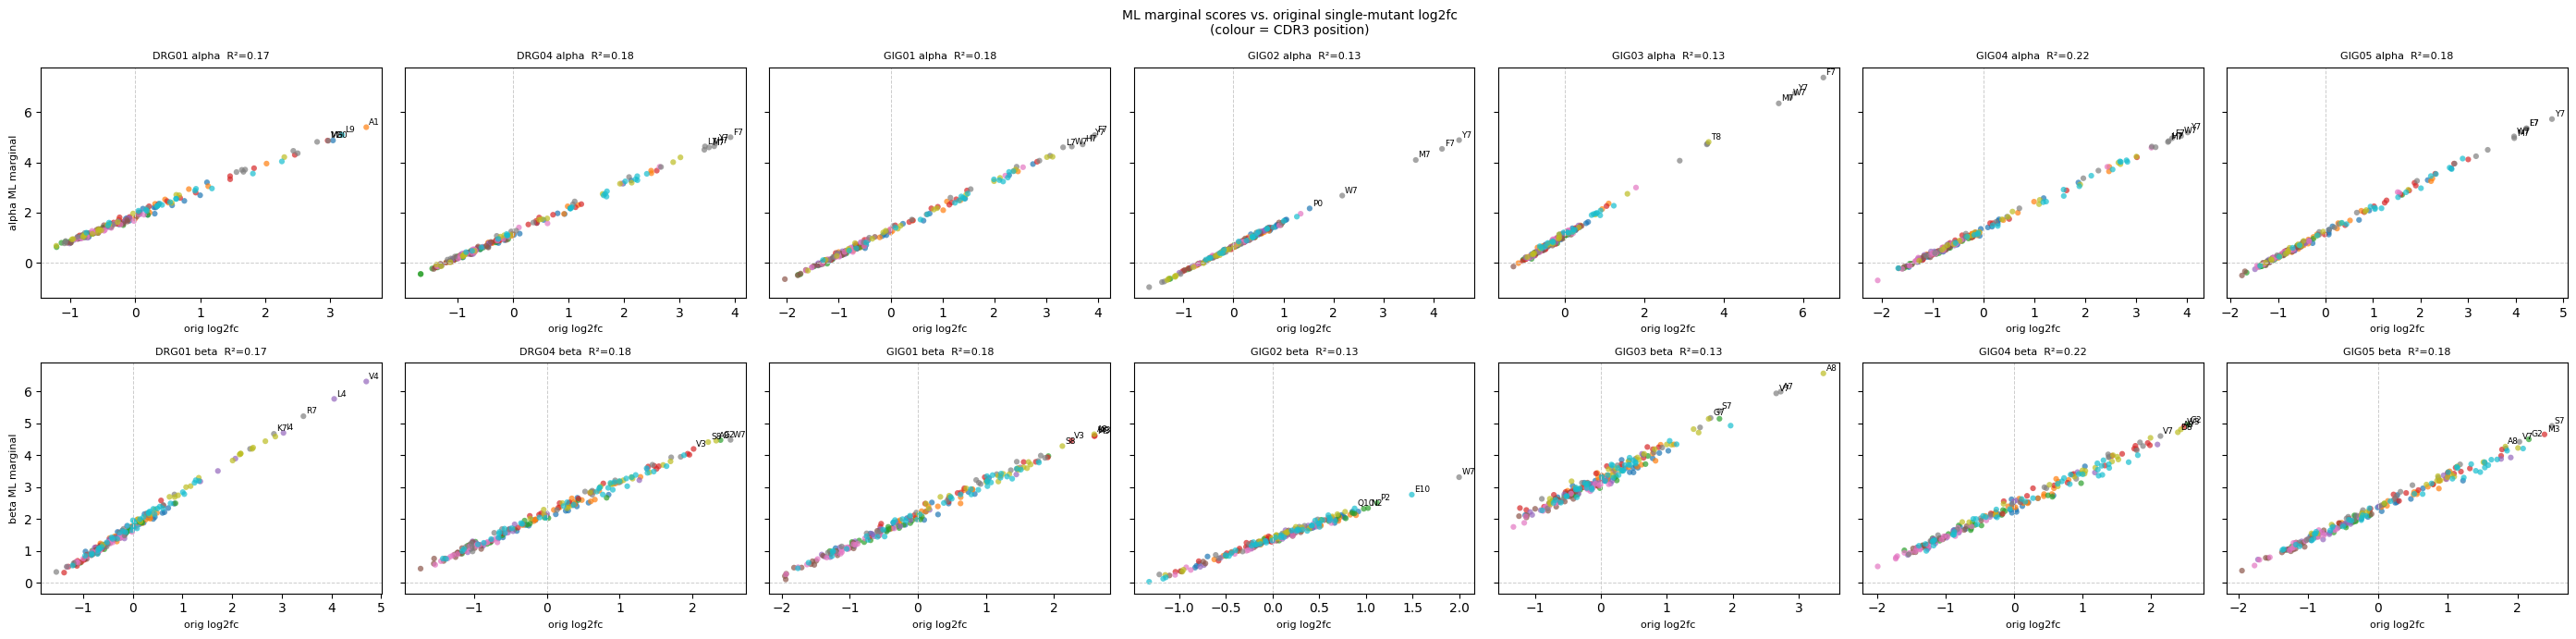

In [13]:
fig, axes = plt.subplots(2, len(PEPTIDES), figsize=(4 * len(PEPTIDES), 7), sharey='row')

for col, pep in enumerate(PEPTIDES):
    for row, chain in enumerate(['alpha', 'beta']):
        ax = axes[row, col]
        ml     = ML_MARGINALS[pep].query(f"chain=='{chain}'")
        orig   = SINGLE_FX[pep][SINGLE_FX[pep]['chain'] == chain]
        merged = ml.merge(orig[['position','aa','log2fc']], on=['position','aa'], how='inner')

        ax.scatter(merged['log2fc'], merged['ml_score'],
                   c=merged['position'], cmap='tab10', alpha=0.7, s=20, linewidths=0)
        for _, r in merged.nlargest(5, 'ml_score').iterrows():
            ax.annotate(f'{r["aa"]}{int(r["position"])}',
                        (r['log2fc'], r['ml_score']), fontsize=6.5,
                        xytext=(2, 2), textcoords='offset points')

        ax.axhline(0, color='#ccc', lw=0.7, ls='--')
        ax.axvline(0, color='#ccc', lw=0.7, ls='--')
        ax.set_xlabel('orig log2fc', fontsize=8)
        if col == 0:
            ax.set_ylabel(f'{chain} ML marginal', fontsize=8)
        ax.set_title(f'{pep} {chain}  R²={ML_R2[pep]:.2f}', fontsize=8)

plt.suptitle('ML marginal scores vs. original single-mutant log2fc\n(colour = CDR3 position)',
             fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / 'ml_marginals_vs_orig.pdf', bbox_inches='tight')
plt.show()

## Composite Score Function and Library Design

`pool_ml_composite_scores` is a drop-in replacement for the original `pool_composite_scores`.
It z-scores the ML marginals; no separate synergy bonus is needed because the model has
already learned the interchain context.

In [14]:
def pool_ml_composite_scores(pep_list, chain):
    dfs = [ML_MARGINALS[p][ML_MARGINALS[p]['chain'] == chain][['position','aa','ml_score']]
           for p in pep_list if p in ML_MARGINALS]
    pooled = (pd.concat(dfs, ignore_index=True)
              .groupby(['position','aa'])['ml_score'].mean().reset_index()
              .rename(columns={'ml_score': 'base_score'}))
    mu    = pooled['base_score'].mean()
    sigma = pooled['base_score'].std()
    pooled['z_base']    = (pooled['base_score'] - mu) / (sigma if sigma > 0 else 1.0)
    pooled['composite'] = pooled['z_base']
    return pooled.sort_values(['position','composite'], ascending=[True, False])


print('DRG01 alpha — top-8 ML composite scores:')
print(pool_ml_composite_scores(['DRG01'], 'alpha').nlargest(8, 'composite').to_string(index=False))
print('\nDRG01 beta — top-8 ML composite scores:')
print(pool_ml_composite_scores(['DRG01'], 'beta').nlargest(8, 'composite').to_string(index=False))

DRG01 alpha — top-8 ML composite scores:
 position aa  base_score   z_base  composite
        1  A    5.399666 3.688837   3.688837
        9  L    5.097364 3.372763   3.372763
        0  G    4.873133 3.138317   3.138317
        3  M    4.867684 3.132619   3.132619
        7  V    4.861158 3.125796   3.125796
        7  L    4.816486 3.079089   3.079089
        7  F    4.459513 2.705853   2.705853
        7  M    4.363911 2.605895   2.605895

DRG01 beta — top-8 ML composite scores:
 position aa  base_score   z_base  composite
        4  V    6.314060 4.588406   4.588406
        4  L    5.769065 4.038746   4.038746
        7  R    5.226287 3.491322   3.491322
        4  I    4.703159 2.963716   2.963716
        7  K    4.673941 2.934248   2.934248
        8  K    4.587353 2.846919   2.846919
        8  I    4.442937 2.701267   2.701267
        8  M    4.242480 2.499093   2.499093


In [15]:
# ── Oligo construction helpers (copied from original notebook) ────────────

def _wt_triplets(wt_seq):
    t = {}
    for pos, aa in enumerate(wt_seq):
        for codon, enc_aa in GENETIC_CODE.items():
            if enc_aa == aa: t[pos] = codon; break
    return t


def _canonical_codon(pos, cands_by_pos, scores_by_pos, wt_aa=None, top_k=1):
    if pos not in cands_by_pos or not cands_by_pos[pos]:
        return None, frozenset(), 0.0
    top_aas   = [cands_by_pos[pos][i][0]
                 for i in range(min(top_k, len(cands_by_pos[pos])))]
    must_have = frozenset(top_aas) | (frozenset({wt_aa}) if wt_aa is not None else frozenset())
    pos_scores = scores_by_pos.get(pos, {})
    best_triplet, best_encoded, best_mean = None, frozenset(), -np.inf
    for triplet, props in IUPAC_PROPS.items():
        encoded = props['aas']
        if not must_have.issubset(encoded):
            continue
        mean_score = (
            sum(pos_scores.get(aa, 0.0) for aa in encoded)
            - STOP_PENALTY * props['stop_frac']
        ) / max(len(encoded), 1)
        if mean_score > best_mean:
            best_mean    = mean_score
            best_triplet = triplet
            best_encoded = encoded
    if best_triplet is None:
        return None, frozenset(), 0.0
    return best_triplet, frozenset(best_encoded), len(must_have) / len(best_encoded)


def _make_paired_oligo(oligo_id, oligo_type, alpha_enc, beta_enc,
                       wt_alpha, wt_beta, wt_tri_alpha, wt_tri_beta):
    alpha_len = len(wt_alpha)
    beta_len  = len(wt_beta)
    alpha_pos_aas = {p: frozenset({wt_alpha[p]}) for p in range(alpha_len)}
    beta_pos_aas  = {p: frozenset({wt_beta[p]})  for p in range(beta_len)}
    alpha_iupac   = dict(wt_tri_alpha)
    beta_iupac    = dict(wt_tri_beta)
    effs      = {}
    diversity = 1
    for pos, (triplet, encoded, eff) in alpha_enc.items():
        alpha_pos_aas[pos] = encoded; alpha_iupac[pos] = triplet
        effs[('alpha', pos)] = eff;   diversity *= len(encoded)
    for pos, (triplet, encoded, eff) in beta_enc.items():
        beta_pos_aas[pos] = encoded; beta_iupac[pos] = triplet
        effs[('beta', pos)] = eff;   diversity *= len(encoded)
    alpha_dna = ''.join(alpha_iupac[p] for p in range(alpha_len))
    beta_dna  = ''.join(beta_iupac[p]  for p in range(beta_len))
    return {
        'oligo_id':           oligo_id,
        'oligo_type':         oligo_type,
        'alpha_position_aas': alpha_pos_aas,
        'beta_position_aas':  beta_pos_aas,
        'alpha_iupac':        alpha_iupac,
        'beta_iupac':         beta_iupac,
        'alpha_dna':          alpha_dna,
        'beta_dna':           beta_dna,
        'paired_dna':         alpha_dna + beta_dna,
        'diversity':          diversity,
        'codon_efficiency':   effs,
        'is_leaky':           any(e < EFFICIENCY_THRESH for e in effs.values()),
        'alpha_varied_pos':   sorted(p for p, aas in alpha_pos_aas.items() if len(aas) > 1),
        'beta_varied_pos':    sorted(p for p, aas in beta_pos_aas.items()  if len(aas) > 1),
        'n_alpha_varied':     sum(1 for aas in alpha_pos_aas.values() if len(aas) > 1),
        'n_beta_varied':      sum(1 for aas in beta_pos_aas.values()  if len(aas) > 1),
    }


def design_paired_pool_ml(pep, wt_alpha, wt_beta, target_diversity, max_diversity):
    """Design a TCRAFT paired oPool using ML-derived composite scores."""
    wt_tri_alpha = _wt_triplets(wt_alpha)
    wt_tri_beta  = _wt_triplets(wt_beta)

    alpha_df = pool_ml_composite_scores([pep], 'alpha')
    beta_df  = pool_ml_composite_scores([pep], 'beta')

    scores_by_key = {}
    cands_by_key  = {}
    for chain, df in [('alpha', alpha_df), ('beta', beta_df)]:
        for _, row in df.iterrows():
            key = (chain, int(row['position']))
            scores_by_key.setdefault(key, {})[row['aa']] = row['composite']
        for pos, grp in df.groupby('position'):
            top = (grp[grp['composite'] >= MIN_SCORE]
                   .nlargest(K_MAX, 'composite')[['aa', 'composite']].values.tolist())
            if top:
                cands_by_key[(chain, int(pos))] = top

    canon = {}
    for (chain, pos), cands in cands_by_key.items():
        wt_seq = wt_alpha if chain == 'alpha' else wt_beta
        t, enc, eff = _canonical_codon(
            pos, {pos: cands}, {pos: scores_by_key[(chain, pos)]},
            wt_aa=wt_seq[pos], top_k=TOP_K
        )
        if t is not None:
            canon[(chain, pos)] = (t, enc, eff)

    sorted_pos = sorted(
        cands_by_key,
        key=lambda k: max(sc for _, sc in cands_by_key[k]),
        reverse=True
    )
    n_pos = len(sorted_pos)

    tier1, tier2, tier3 = [], [], []
    tier1_div    = 1
    tier1_budget = int(target_diversity * TIER1_FRAC)

    for key in sorted_pos:
        chain_k, pos_k = key
        if key not in canon:      tier3.append(key); continue
        if pos_k in TIER1_EXCLUDE.get(chain_k, set()): continue
        proposed = tier1_div * len(canon[key][1])
        if proposed > tier1_budget: continue
        tier1_div = proposed
        tier1.append(key)

    remaining = [k for k in sorted_pos if k not in set(tier1)]
    if TIER1_FRAC < 1.0:
        ext_budget = target_diversity - tier1_div
        for key in remaining:
            if key not in canon:      tier3.append(key); continue
            cost = tier1_div * (len(canon[key][1]) - 1)
            if cost > ext_budget:     continue
            if tier1_div + cost > max_diversity: continue
            tier2.append(key)
            ext_budget -= cost

    in_t1t2 = set(tier1 + tier2)
    tier3 += [k for k in sorted_pos if k not in in_t1t2 and k not in tier3]

    total_div = tier1_div + sum(
        tier1_div * (len(canon[k][1]) - 1) for k in tier2 if k in canon
    )

    t1a = sorted(p for c, p in tier1 if c == 'alpha')
    t1b = sorted(p for c, p in tier1 if c == 'beta')
    t2a = sorted(p for c, p in tier2 if c == 'alpha')
    t2b = sorted(p for c, p in tier2 if c == 'beta')
    print(f'  {n_pos} enriched positions across both chains  [TOP_K={TOP_K}]')
    print(f'  Tier 1 ({len(tier1)} pos):  alpha={t1a}  beta={t1b}  — backbone div = {tier1_div:,}')
    print(f'  Tier 2 ({len(tier2)} pos):  alpha_ext={t2a}  beta_ext={t2b}')
    print(f'  Tier 3 ({len(tier3)} pos):  {tier3}')
    print(f'  Estimated diversity: {total_div:,}  (target {target_diversity:,}  max {max_diversity:,})')

    def a_enc(keys):
        return {p: canon[('alpha', p)] for (c, p) in keys if c=='alpha' and ('alpha',p) in canon}
    def b_enc(keys):
        return {p: canon[('beta',  p)] for (c, p) in keys if c=='beta'  and ('beta', p) in canon}

    seen_dna = set()
    oligos   = []

    def add(oligo):
        if oligo['paired_dna'] not in seen_dna:
            seen_dna.add(oligo['paired_dna']); oligos.append(oligo); return True
        return False

    tier1_set = set(tier1)
    add(_make_paired_oligo(f'{pep}_backbone', 'tier1_backbone',
                           a_enc(tier1_set), b_enc(tier1_set),
                           wt_alpha, wt_beta, wt_tri_alpha, wt_tri_beta))

    for key in tier2:
        chain_k, pos_k = key
        ext_set = tier1_set | {key}
        label   = f'{"a" if chain_k=="alpha" else "b"}p{pos_k:02d}'
        add(_make_paired_oligo(f'{pep}_ext_{label}', 'tier2_ext',
                               a_enc(ext_set), b_enc(ext_set),
                               wt_alpha, wt_beta, wt_tri_alpha, wt_tri_beta))

    for o in oligos:
        o['unique_diversity'] = (o['diversity'] if o['oligo_type'] == 'tier1_backbone'
                                 else o['diversity'] - tier1_div)

    if total_div < target_diversity * 0.7:
        print(f'  NOTE: diversity {total_div:,} is below 70% of target {target_diversity:,}')
    print(f'  Total oligos: {len(oligos)}')
    return oligos


print(f'Designing {len(PEPTIDES)} ML-guided paired pools...')
POOLS_ML = {}
for pep in PEPTIDES:
    print(f'\n── {pep} ──')
    POOLS_ML[pep] = design_paired_pool_ml(
        pep, WT_ALPHA, WT_BETA, TARGET_DIVERSITY, MAX_DIVERSITY
    )

Designing 7 ML-guided paired pools...

── DRG01 ──
  15 enriched positions across both chains  [TOP_K=0]
  Tier 1 (12 pos):  alpha=[1, 3, 7, 8, 9]  beta=[2, 3, 4, 7, 8, 9, 10]  — backbone div = 1,474,560
  Tier 2 (2 pos):  alpha_ext=[0]  beta_ext=[0]
  Tier 3 (1 pos):  [('beta', 1)]
  Estimated diversity: 7,372,800  (target 10,000,000  max 15,000,000)
  Total oligos: 3

── DRG04 ──
  16 enriched positions across both chains  [TOP_K=0]
  Tier 1 (13 pos):  alpha=[1, 3, 6, 7, 8, 9]  beta=[2, 3, 4, 7, 8, 9, 10]  — backbone div = 2,949,120
  Tier 2 (0 pos):  alpha_ext=[]  beta_ext=[]
  Tier 3 (3 pos):  [('alpha', 0), ('beta', 1), ('beta', 0)]
  Estimated diversity: 2,949,120  (target 10,000,000  max 15,000,000)
  NOTE: diversity 2,949,120 is below 70% of target 10,000,000
  Total oligos: 1

── GIG01 ──
  16 enriched positions across both chains  [TOP_K=0]
  Tier 1 (10 pos):  alpha=[1, 3, 6, 7, 8, 9]  beta=[2, 3, 7, 8]  — backbone div = 2,236,416
  Tier 2 (1 pos):  alpha_ext=[0]  beta_ext=[]

## Diversity Check

In [16]:
print(f'{"Peptide":<8}  {"n_oligos":>9}  {"backbone_div":>14}  {"total_div":>11}  {"target":>11}  flag')
print('-' * 70)
for pep in PEPTIDES:
    pool     = POOLS_ML[pep]
    backbone = next((o for o in pool if o['oligo_type'] == 'tier1_backbone'), None)
    bd       = backbone['diversity'] if backbone else '-'
    total    = sum(o['unique_diversity'] for o in pool)
    flag     = 'OVER MAX!' if total > MAX_DIVERSITY else ('OK' if total <= TARGET_DIVERSITY * 1.1 else 'above target')
    types    = {}
    for o in pool: types[o['oligo_type']] = types.get(o['oligo_type'], 0) + 1
    print(f'{pep:<8}  {len(pool):>9}  {bd:>14,}  {total:>11,}  {TARGET_DIVERSITY:>11,}  {flag}  {types}')

Peptide    n_oligos    backbone_div    total_div       target  flag
----------------------------------------------------------------------
DRG01             3       1,474,560    7,372,800   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 2}
DRG04             1       2,949,120    2,949,120   10,000,000  OK  {'tier1_backbone': 1}
GIG01             2       2,236,416    8,945,664   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 1}
GIG02             2       2,985,984    5,971,968   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 1}
GIG03             3       2,064,384    8,257,536   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 2}
GIG04             4       1,105,920    8,847,360   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 3}
GIG05             3       1,866,240    9,331,200   10,000,000  OK  {'tier1_backbone': 1, 'tier2_ext': 2}


## Comparison: ML vs. Original Heuristic Design

Re-run the heuristic (position-level synergy bonus) design to generate a side-by-side comparison.

In [17]:
# ── Heuristic composite score (needed only for comparison) ───────────────
def synergy_bonus_for_chain(pep_list, chain, min_epi=0.2):
    all_epi = pd.concat([EPISTASIS[p] for p in pep_list if not EPISTASIS[p].empty], ignore_index=True)
    if chain == 'alpha': pos_col, aa_col = 'alpha_pos','aa_alpha'
    else:                pos_col, aa_col = 'beta_pos', 'aa_beta'
    opos_col = 'beta_pos' if chain == 'alpha' else 'alpha_pos'
    pooled = all_epi.groupby([pos_col, aa_col, opos_col])['epistasis'].mean().reset_index()
    syn = defaultdict(float)
    for _, row in pooled.iterrows():
        if row['epistasis'] > min_epi:
            syn[(int(row[pos_col]), row[aa_col])] += row['epistasis']
    return dict(syn)

def pool_composite_scores(pep_list, chain):
    chain_dfs = [SINGLE_FX[p][SINGLE_FX[p]['chain']==chain] for p in pep_list if p in SINGLE_FX]
    pooled = (pd.concat(chain_dfs, ignore_index=True)
              .groupby(['position','aa'])['log2fc'].mean().reset_index()
              .rename(columns={'log2fc':'base_score'}))
    syn_raw = synergy_bonus_for_chain(pep_list, chain)
    pooled['syn_raw'] = pooled.apply(lambda r: syn_raw.get((int(r['position']), r['aa']), 0.0), axis=1)
    pooled['z_base']  = (pooled['base_score'] - pooled['base_score'].mean()) / pooled['base_score'].std()
    syn_std = pooled['syn_raw'].std()
    pooled['z_syn']   = (pooled['syn_raw'] - pooled['syn_raw'].mean()) / (syn_std if syn_std > 0 else 1.0)
    pooled['composite'] = pooled['z_base'] + SYN_WEIGHT * pooled['z_syn']
    return pooled.sort_values(['position','composite'], ascending=[True,False])

def design_paired_pool_heuristic(pep, wt_alpha, wt_beta, target_diversity, max_diversity):
    """Heuristic design (same logic as original notebook) — used only for comparison."""
    wt_tri_alpha = _wt_triplets(wt_alpha)
    wt_tri_beta  = _wt_triplets(wt_beta)
    alpha_df = pool_composite_scores([pep], 'alpha')
    beta_df  = pool_composite_scores([pep], 'beta')
    scores_by_key = {}; cands_by_key = {}
    for chain, df in [('alpha', alpha_df), ('beta', beta_df)]:
        for _, row in df.iterrows():
            key = (chain, int(row['position']))
            scores_by_key.setdefault(key, {})[row['aa']] = row['composite']
        for pos, grp in df.groupby('position'):
            top = (grp[grp['composite'] >= MIN_SCORE]
                   .nlargest(K_MAX, 'composite')[['aa','composite']].values.tolist())
            if top: cands_by_key[(chain, int(pos))] = top
    canon = {}
    for (chain, pos), cands in cands_by_key.items():
        wt_seq = wt_alpha if chain == 'alpha' else wt_beta
        t, enc, eff = _canonical_codon(pos, {pos: cands}, {pos: scores_by_key[(chain,pos)]},
                                        wt_aa=wt_seq[pos], top_k=TOP_K)
        if t is not None: canon[(chain, pos)] = (t, enc, eff)
    sorted_pos = sorted(cands_by_key, key=lambda k: max(sc for _,sc in cands_by_key[k]), reverse=True)
    tier1, tier2, tier3 = [], [], []; tier1_div = 1
    tier1_budget = int(target_diversity * TIER1_FRAC)
    for key in sorted_pos:
        chain_k, pos_k = key
        if key not in canon:      tier3.append(key); continue
        if pos_k in TIER1_EXCLUDE.get(chain_k, set()): continue
        proposed = tier1_div * len(canon[key][1])
        if proposed > tier1_budget: continue
        tier1_div = proposed; tier1.append(key)
    remaining = [k for k in sorted_pos if k not in set(tier1)]
    if TIER1_FRAC < 1.0:
        ext_budget = target_diversity - tier1_div
        for key in remaining:
            if key not in canon:      tier3.append(key); continue
            cost = tier1_div * (len(canon[key][1]) - 1)
            if cost > ext_budget or tier1_div + cost > max_diversity: continue
            tier2.append(key); ext_budget -= cost
    in_t1t2 = set(tier1 + tier2)
    tier3 += [k for k in sorted_pos if k not in in_t1t2 and k not in tier3]
    def a_enc(keys):
        return {p: canon[('alpha',p)] for (c,p) in keys if c=='alpha' and ('alpha',p) in canon}
    def b_enc(keys):
        return {p: canon[('beta',p)]  for (c,p) in keys if c=='beta'  and ('beta',p)  in canon}
    seen_dna = set(); oligos = []
    def add(o):
        if o['paired_dna'] not in seen_dna: seen_dna.add(o['paired_dna']); oligos.append(o)
    tier1_set = set(tier1)
    add(_make_paired_oligo(f'{pep}_backbone','tier1_backbone',
                           a_enc(tier1_set),b_enc(tier1_set),
                           wt_alpha,wt_beta,wt_tri_alpha,wt_tri_beta))
    for key in tier2:
        chain_k,pos_k = key; ext_set = tier1_set | {key}
        label = f'{"a" if chain_k=="alpha" else "b"}p{pos_k:02d}'
        add(_make_paired_oligo(f'{pep}_ext_{label}','tier2_ext',
                               a_enc(ext_set),b_enc(ext_set),
                               wt_alpha,wt_beta,wt_tri_alpha,wt_tri_beta))
    for o in oligos:
        o['unique_diversity'] = (o['diversity'] if o['oligo_type']=='tier1_backbone'
                                 else o['diversity'] - tier1_div)
    return oligos

print('Running heuristic design for comparison...')
POOLS_HEURISTIC = {pep: design_paired_pool_heuristic(
    pep, WT_ALPHA, WT_BETA, TARGET_DIVERSITY, MAX_DIVERSITY) for pep in PEPTIDES}
print('Done.')

Running heuristic design for comparison...
Done.


In [18]:
# ── Summary table ─────────────────────────────────────────────────────────
print(f'{"Peptide":<8}  {"R²":>6}  {"H oligos":>9}  {"H div":>12}  {"ML oligos":>10}  {"ML div":>12}')
print('─' * 65)
for pep in PEPTIDES:
    hd = sum(o['unique_diversity'] for o in POOLS_HEURISTIC[pep])
    md = sum(o['unique_diversity'] for o in POOLS_ML[pep])
    print(f'{pep:<8}  {ML_R2[pep]:>6.3f}  {len(POOLS_HEURISTIC[pep]):>9}  {hd:>12,}  '
          f'{len(POOLS_ML[pep]):>10}  {md:>12,}')

# ── IUPAC codon diffs for highest-R² peptide ─────────────────────────────
ref_pep = max(PEPTIDES, key=lambda p: ML_R2[p])
print(f'\n── Changed backbone IUPAC codons — {ref_pep}  (R²={ML_R2[ref_pep]:.3f}) ──')
orig_bb = next(o for o in POOLS_HEURISTIC[ref_pep] if o['oligo_type'] == 'tier1_backbone')
ml_bb   = next(o for o in POOLS_ML[ref_pep]        if o['oligo_type'] == 'tier1_backbone')

diffs = []
for chain, iupac_key, wt_seq in [('alpha','alpha_iupac',WT_ALPHA),
                                   ('beta', 'beta_iupac', WT_BETA)]:
    for pos in range(len(wt_seq)):
        oc = orig_bb[iupac_key][pos]
        mc = ml_bb[iupac_key][pos]
        if oc != mc:
            o_aas = IUPAC_PROPS.get(oc, {}).get('aas', set())
            m_aas = IUPAC_PROPS.get(mc, {}).get('aas', set())
            diffs.append({'chain': chain, 'pos': pos, 'wt': wt_seq[pos],
                          'heuristic_codon': oc, 'heuristic_aas': ''.join(sorted(o_aas)),
                          'ml_codon': mc, 'ml_aas': ''.join(sorted(m_aas)),
                          'dropped': ''.join(sorted(o_aas - m_aas)),
                          'gained':  ''.join(sorted(m_aas - o_aas))})

if diffs:
    print(pd.DataFrame(diffs).to_string(index=False))
else:
    print('No backbone codon changes for this peptide.')

Peptide       R²   H oligos         H div   ML oligos        ML div
─────────────────────────────────────────────────────────────────
DRG01      0.172          4     7,741,440           3     7,372,800
DRG04      0.179          2     8,601,600           1     2,949,120
GIG01      0.184          2     8,294,400           2     8,945,664
GIG02      0.134          3     9,953,280           2     5,971,968
GIG03      0.134          2     9,437,184           3     8,257,536
GIG04      0.221          3     9,123,840           4     8,847,360
GIG05      0.181          3     8,640,000           3     9,331,200

── Changed backbone IUPAC codons — GIG04  (R²=0.221) ──
chain  pos wt heuristic_codon heuristic_aas ml_codon ml_aas dropped gained
alpha    3  F             TTC             F      TWC     FY              Y
alpha    7  K             WDB   CFIKLMNRSWY      WDG  KLMRW  CFINSY       
 beta    3  L             WYA          ILST      HYR ILMPST             MP
 beta    7  T             RBC    

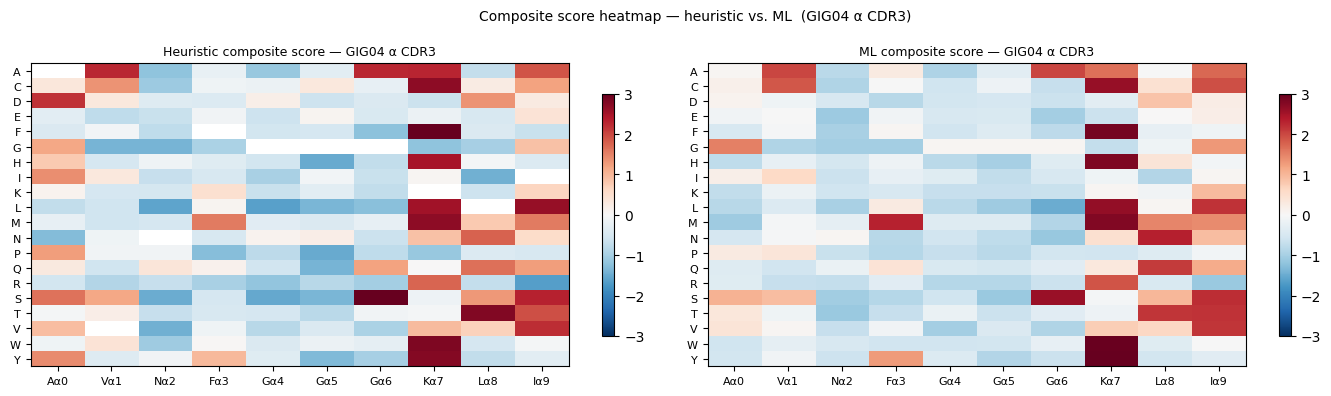

In [19]:
# ── Heatmap: composite score comparison (alpha CDR3, ref peptide) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (title, fn) in zip(axes, [
    ('Heuristic composite score', pool_composite_scores),
    ('ML composite score',        pool_ml_composite_scores),
]):
    df    = fn([ref_pep], 'alpha')
    pivot = (df.pivot_table(index='aa', columns='position', values='composite', aggfunc='mean')
               .reindex(index=list('ACDEFGHIKLMNPQRSTVWY')))
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)
    ax.set_xticks(range(ALPHA_LEN))
    ax.set_xticklabels([f'{wt}α{i}' for i, wt in enumerate(WT_ALPHA)], fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(f'{title} — {ref_pep} α CDR3', fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(f'Composite score heatmap — heuristic vs. ML  ({ref_pep} α CDR3)', fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / f'ml_vs_heuristic_heatmap_{ref_pep}.pdf', bbox_inches='tight')
plt.show()

## Export ML-Guided oPool to CSV

In [20]:
def pool_to_df(pep, pool):
    rows, cumul = [], 0
    for o in pool:
        cumul += o['unique_diversity']
        alpha_var = '; '.join(
            f'p{p}:[{",".join(sorted(o["alpha_position_aas"][p]))}]'
            for p in o['alpha_varied_pos']
        )
        beta_var = '; '.join(
            f'p{p}:[{",".join(sorted(o["beta_position_aas"][p]))}]'
            for p in o['beta_varied_pos']
        )
        effs = [e for e in o['codon_efficiency'].values() if e < 1.0]
        rows.append({
            'oligo_id':               o['oligo_id'],
            'oligo_type':             o['oligo_type'],
            'alpha_dna':              o['alpha_dna'],
            'beta_dna':               o['beta_dna'],
            'paired_dna':             o['paired_dna'],
            'paired_dna_length_nt':   len(o['paired_dna']),
            'n_alpha_varied':         o['n_alpha_varied'],
            'n_beta_varied':          o['n_beta_varied'],
            'alpha_varied_positions': alpha_var,
            'beta_varied_positions':  beta_var,
            'diversity':              o['diversity'],
            'unique_diversity':       o['unique_diversity'],
            'cumulative_diversity':   cumul,
            'mean_codon_efficiency':  round(np.mean(effs), 3) if effs else 1.0,
            'is_leaky':               o.get('is_leaky', False),
        })
    return pd.DataFrame(rows)


idt_rows = []
for pep, pool in POOLS_ML.items():
    df   = pool_to_df(pep, pool)
    path = OUT_DIR / f'opool_paired_ml_{pep}.csv'
    df.to_csv(path, index=False)
    print(f'Wrote {path}  ({len(df)} oligos)')
    display(df[['oligo_id','oligo_type','alpha_dna','beta_dna',
                'n_alpha_varied','n_beta_varied','diversity','unique_diversity']])
    order = df[['oligo_id', 'paired_dna']].copy()
    order.insert(0, 'Pool Name', pep)
    idt_rows.append(order)

idt_df   = pd.concat(idt_rows, ignore_index=True)
idt_df   = idt_df.rename(columns={'oligo_id': 'Sequence Name',
                                   'paired_dna': 'Sequence (no adapters)'})
idt_path = OUT_DIR / 'IDT_opool_paired_ml_order.csv'
idt_df.to_csv(idt_path, index=False)
print(f'\nIDT order sheet → {idt_path}  ({len(idt_df)} oligos total)')

Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft_ml/opool_paired_ml_DRG01.csv  (3 oligos)


,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,DRG01_backbone,tier1_backbone,GCAGYAAACWTSGGAGGAGGAADRWTGWTR,GCAAGCYCAMKGKYATTCGGAANGRWRRCANKC,5,7,1474560,1474560
1,DRG01_ext_ap00,tier2_ext,GSAGYAAACWTSGGAGGAGGAADRWTGWTR,GCAAGCYCAMKGKYATTCGGAANGRWRRCANKC,6,7,2949120,1474560
2,DRG01_ext_bp00,tier2_ext,GCAGYAAACWTSGGAGGAGGAADRWTGWTR,RMCAGCYCAMKGKYATTCGGAANGRWRRCANKC,5,8,5898240,4423680


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft_ml/opool_paired_ml_DRG04.csv  (1 oligos)


,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,DRG04_backbone,tier1_backbone,GCAGYAAACWTSGGAGGARGCWDGWYGDYA,GCAAGCRGCDTRKCATTCGGARYGGMSSCAYWC,6,7,2949120,2949120


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft_ml/opool_paired_ml_GIG01.csv  (2 oligos)


...

Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft_ml/opool_paired_ml_GIG04.csv  (4 oligos)


,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,GIG04_backbone,tier1_backbone,GCAGYAAACTWCGGAGGARGCWDGWYGDYA,GCAAGCRGCHYRKCATTCGGADYAGVSSCATTC,6,6,1105920,1105920
1,GIG04_ext_bp10,tier2_ext,GCAGYAAACTWCGGAGGARGCWDGWYGDYA,GCAAGCRGCHYRKCATTCGGADYAGVSSCAHWC,6,7,6635520,5529600
2,GIG04_ext_ap00,tier2_ext,GSAGYAAACTWCGGAGGARGCWDGWYGDYA,GCAAGCRGCHYRKCATTCGGADYAGVSSCATTC,7,6,2211840,1105920
3,GIG04_ext_bp00,tier2_ext,GCAGYAAACTWCGGAGGARGCWDGWYGDYA,GSAAGCRGCHYRKCATTCGGADYAGVSSCATTC,6,7,2211840,1105920


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft_ml/opool_paired_ml_GIG05.csv  (3 oligos)


,oligo_id,oligo_type,alpha_dna,beta_dna,n_alpha_varied,n_beta_varied,diversity,unique_diversity
0,GIG05_backbone,tier1_backbone,GCARTAAACDYSGGAGGAGGAWDGCTAWYA,GCAAGCRGCDTGAVCTTCGGARBCGMSSCADHC,4,7,1866240,1866240
1,GIG05_ext_ap00,tier2_ext,RSCRTAAACDYSGGAGGAGGAWDGCTAWYA,GCAAGCRGCDTGAVCTTCGGARBCGMSSCADHC,5,7,7464960,5598720
2,GIG05_ext_bp00,tier2_ext,GCARTAAACDYSGGAGGAGGAWDGCTAWYA,GSAAGCRGCDTGAVCTTCGGARBCGMSSCADHC,4,8,3732480,1866240



IDT order sheet → /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs_tcraft_ml/IDT_opool_paired_ml_order.csv  (18 oligos total)
